### Practicing with random graph generators

- Code to create graphs using $G(n,m)$
- Emphsizing properties of traphs created using $G(n,p)$

__G(n,m) Algorithm__

- Choose the number of nodes $n$
- Choose the number of edges $m$
- Take the $m$ edges and place them among the $n$ nodes at random

```
    M. Newman, Networks, 2nd edition, Oxford Univ. Press, p. 343, 2018
```

Run the code below. Notice two things
- The random draw of node1 and node2 cannot produce self-loops
- We must have distinct pairs of nodes. In other words, the graph cannot be a multigraph.

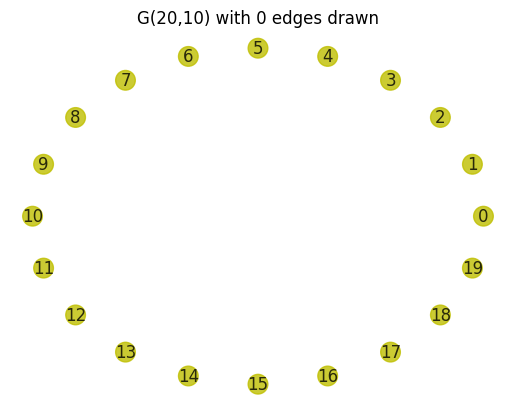

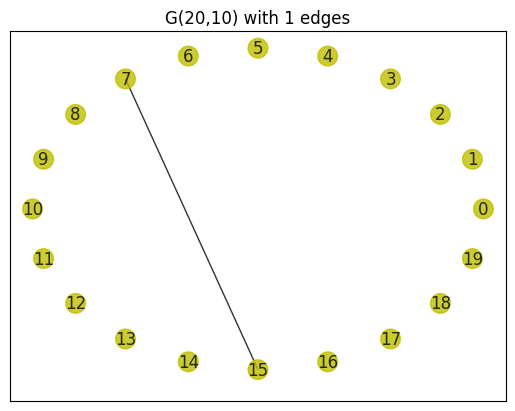

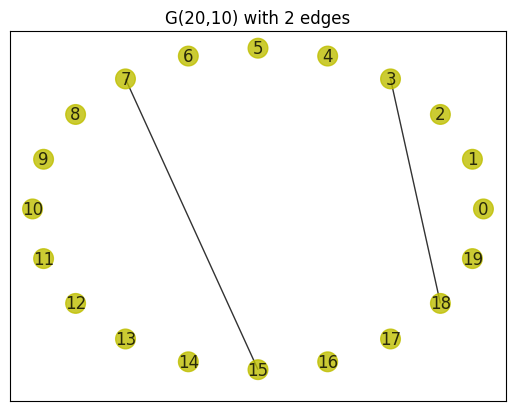

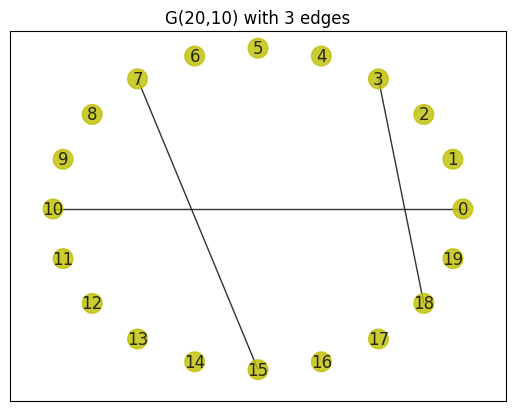

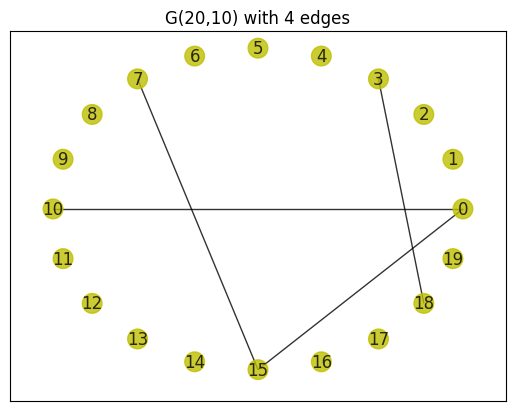

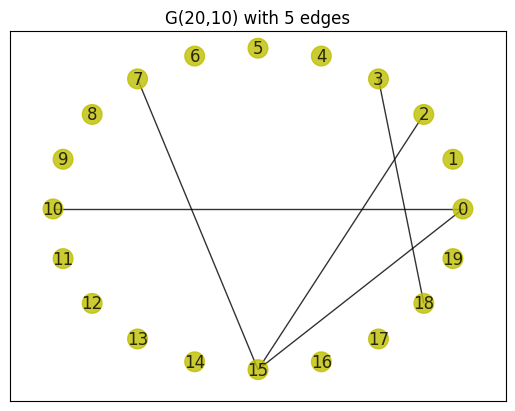

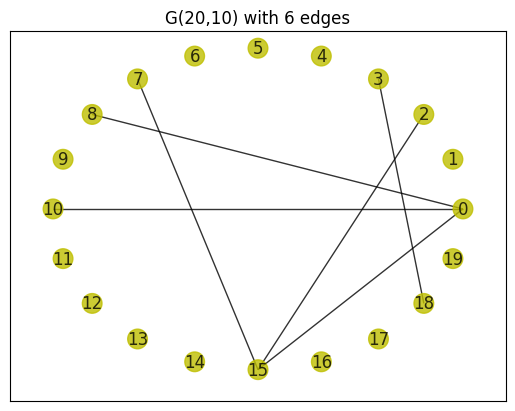

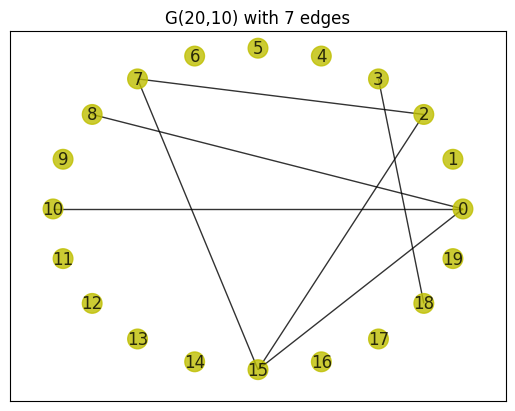

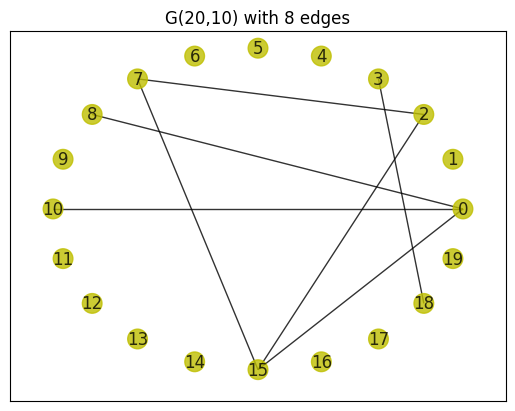

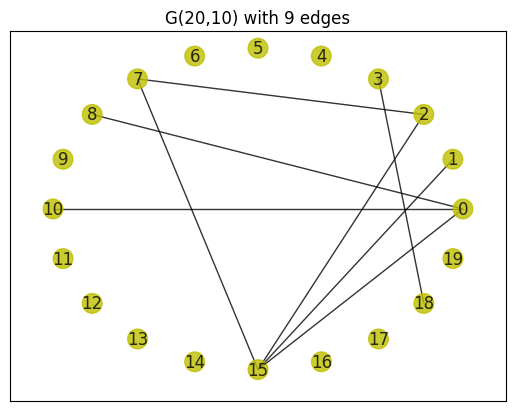

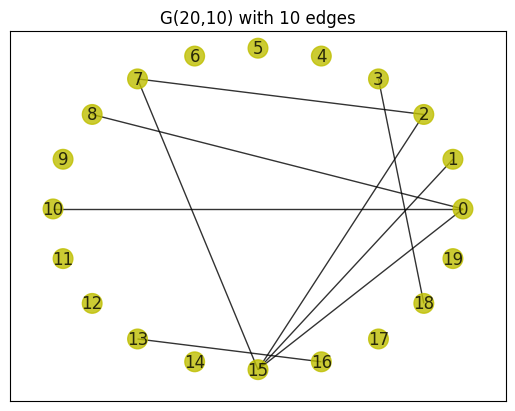

In [111]:
from matplotlib import pyplot as plt
import networkx as nx
import numpy as np
G = nx.Graph()
n = 20; m = 10
G.add_nodes_from(range(0,n))
color_map = ['y' for _ in G.nodes]
pos = nx.circular_layout(G)
plt.figure()
ax = plt.gca()
nx.draw(G,pos,node_color = color_map, node_size = 200, alpha=0.8, with_labels = True)
m_count = 0
title = f"G({n},{m}) with {m_count} edges drawn"
ax.set_title(title)

while m_count < m:
    while True:
        node1 = np.random.randint(0,n)
        node2 = np.random.randint(0,n)
        if node1 == node2: continue
        if (node1,node2) not in set(G.edges):
            G.add_edge(node1,node2)
            break
    m_count += 1
    plt.figure()
    ax = plt.gca()
    nx.draw_networkx(G,pos,node_color = color_map, node_size = 200, alpha=0.8, with_labels = True)
    title = f"G({n},{m}) with {m_count} edges"
    ax.set_title(title)
del(G)


---

__G(n,p)__
- For each pair of vertices $(u,v)$
  - If $\{u,v\} \not\in E$ place edge $\{u,v\}$ in $E$

```
    M. Newman, Networks, 2nd edition, Oxford Univ. Press, p. 344, 2018
```
This cell demonstrates the algorithm. Subsequent cells use 

```
  nx.erdos_renyi_graph(n, p, seed=None, directed=False) ```

Notice that this algorithm does not produce multiedges


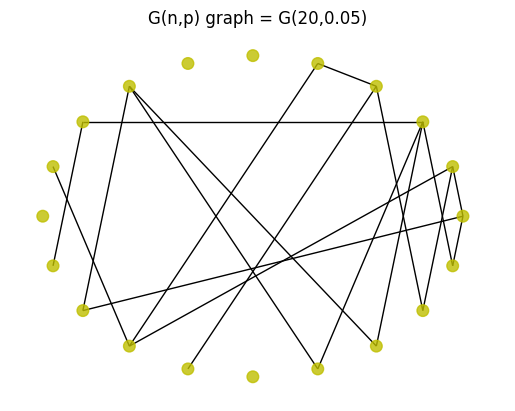

In [112]:
import math
import itertools as iter

# Set the parameters p so that the average number of 
# edges is the same as above for the G(n,m) graph
# <m> = n choose 2 * p
n = 20; m_average = 10; 
p = m_average / math.comb(n,2)
G = nx.Graph()
G.add_nodes_from(range(0,n))
pos = nx.circular_layout(G)
plt.figure()
ax = plt.gca()
nx.draw(G,pos,node_color = color_map, node_size = 70, alpha=0.8)
title = "G(n,p) graph = G("+str(n) + ","+str(np.round(p,2)) + ")"
ax.set_title(title)

node_pairs = iter.product(range(0,n),range(0,n))
for nodes in node_pairs:
    if nodes[0] == nodes[1]: continue
    r = np.random.uniform(0,1)
    if r < p:
        G.add_edge(nodes[0],nodes[1])
        m_count += 1
nx.draw_networkx_edges(G,pos)
print("Notice that this algorithm does not produce multiedges")


In [113]:
from scipy.special import comb
def compute_probability(n,m,p):
    return p**m * ((1-p)**(comb(n,2)-m))
def show_probabilities(n: int, p: float, num_of_edges: list[int]):
    print(f"For p = {p}:")
    for m in num_of_edges:
        print(f"\tthe probability of a graph with {m} edges is {compute_probability(n,m,p):.2e}")

In [116]:
show_probabilities(20,0, [0,1,2,5,10])
show_probabilities(20,0.001, [0,1,2,5,10])

For p = 0:
	the probability of a graph with 0 edges is 1.00e+00
	the probability of a graph with 1 edges is 0.00e+00
	the probability of a graph with 2 edges is 0.00e+00
	the probability of a graph with 5 edges is 0.00e+00
	the probability of a graph with 10 edges is 0.00e+00
For p = 0.001:
	the probability of a graph with 0 edges is 8.27e-01
	the probability of a graph with 1 edges is 8.28e-04
	the probability of a graph with 2 edges is 8.29e-07
	the probability of a graph with 5 edges is 8.31e-16
	the probability of a graph with 10 edges is 8.35e-31


In [115]:
show_probabilities(20,0.01, [0,1,2,5,10])
show_probabilities(20,0.1, [0,1,2,5,10])
show_probabilities(20,0.5, [0,1,2,5,10])
show_probabilities(20,0.8, [0,1,2,5,10])

For p = 0.01:
	the probability of a graph with 0 edges is 1.48e-01
	the probability of a graph with 1 edges is 1.50e-03
	the probability of a graph with 2 edges is 1.51e-05
	the probability of a graph with 5 edges is 1.56e-11
	the probability of a graph with 10 edges is 1.64e-21
For p = 0.1:
	the probability of a graph with 0 edges is 2.02e-09
	the probability of a graph with 1 edges is 2.25e-10
	the probability of a graph with 2 edges is 2.50e-11
	the probability of a graph with 5 edges is 3.43e-14
	the probability of a graph with 10 edges is 5.80e-19
For p = 0.5:
	the probability of a graph with 0 edges is 6.37e-58
	the probability of a graph with 1 edges is 6.37e-58
	the probability of a graph with 2 edges is 6.37e-58
	the probability of a graph with 5 edges is 6.37e-58
	the probability of a graph with 10 edges is 6.37e-58
For p = 0.8:
	the probability of a graph with 0 edges is 1.57e-133
	the probability of a graph with 1 edges is 6.28e-133
	the probability of a graph with 2 edges 

In [71]:
n = 20
p = 0.5
print(f"For p = {p}:")
for m in [0,1,2,3,5,10,20]:
    prob_graph_n_by_m = p**m *(1-p)**(comb(n,2)-m)
    print(f"\tthe probability of a graph with {m} edges is {prob_graph_n_by_m:.2e}")

For p = 0.5:
	the probability of a graph with 0 edges is 6.37e-58
	the probability of a graph with 1 edges is 6.37e-58
	the probability of a graph with 2 edges is 6.37e-58
	the probability of a graph with 3 edges is 6.37e-58
	the probability of a graph with 5 edges is 6.37e-58
	the probability of a graph with 10 edges is 6.37e-58
	the probability of a graph with 20 edges is 6.37e-58


In [134]:
n = 20
p = 0.8
print(f"For p = {p}:")
for m in [0,1,2,3,5,10,n**2-1]:
    prob_graph_n_by_m = p**m *(1-p)**(comb(n,2)-m)
    print(f"\tthe probability of a graph with {m} edges is {prob_graph_n_by_m:.2e}")

For p = 0.8:
	the probability of a graph with 0 edges is 1.57e-133
	the probability of a graph with 1 edges is 6.28e-133
	the probability of a graph with 2 edges is 2.51e-132
	the probability of a graph with 3 edges is 1.00e-131
	the probability of a graph with 5 edges is 1.61e-130
	the probability of a graph with 10 edges is 1.65e-127
	the probability of a graph with 399 edges is 2.62e+107


n = 20
p = 0.01
print(f"For p = {p}:")
for m in [0,1,2,3,5,10,20]:
    prob_graph_n_by_m = p**m *(1-p)**(binom(n,2)-m)
    print(f"\tthe probability of a graph with {m} edges is {prob_graph_n_by_m:.2e}")

In [133]:
n = 20
p = 0.01
m = 1 
num_trials = 100000
prob_graph_n_by_m = p**m *(1-p)**(comb(n,2)-m)
## Create a bunch of graphs and see how often unique graphs with one edge occur ## 
uniqueOneEdgeGraphs = dict()
for i in range(0,num_trials):
    G = nx.erdos_renyi_graph(n,p)
    if len(G.edges) == 1:
        edge = list(G.edges)[0]
        if edge not in uniqueOneEdgeGraphs: uniqueOneEdgeGraphs[edge] = 0
        uniqueOneEdgeGraphs[edge] += 1
print(f"For p = {p}, probability of graph with {1} edge is {compute_probability(n,m,p):.2e}")
for e in uniqueOneEdgeGraphs.keys():
    print(f"\tgraph with edge {e} occurred at rate {uniqueOneEdgeGraphs[e]/num_trials:.2e}")


For p = 0.01, probability of graph with 1 edge is 1.50e-03
	graph with edge (12, 19) occurred at rate 1.60e-03
	graph with edge (0, 10) occurred at rate 1.44e-03
	graph with edge (5, 14) occurred at rate 1.42e-03
	graph with edge (5, 18) occurred at rate 1.49e-03
	graph with edge (13, 16) occurred at rate 1.43e-03
	graph with edge (2, 12) occurred at rate 1.59e-03
	graph with edge (9, 11) occurred at rate 1.40e-03
	graph with edge (3, 15) occurred at rate 1.52e-03
	graph with edge (3, 6) occurred at rate 1.51e-03
	graph with edge (10, 19) occurred at rate 1.63e-03
	graph with edge (4, 11) occurred at rate 1.30e-03
	graph with edge (4, 9) occurred at rate 1.53e-03
	graph with edge (5, 12) occurred at rate 1.24e-03
	graph with edge (6, 13) occurred at rate 1.63e-03
	graph with edge (0, 13) occurred at rate 1.50e-03
	graph with edge (12, 14) occurred at rate 1.52e-03
	graph with edge (4, 19) occurred at rate 1.33e-03
	graph with edge (0, 9) occurred at rate 1.56e-03
	graph with edge (13, 

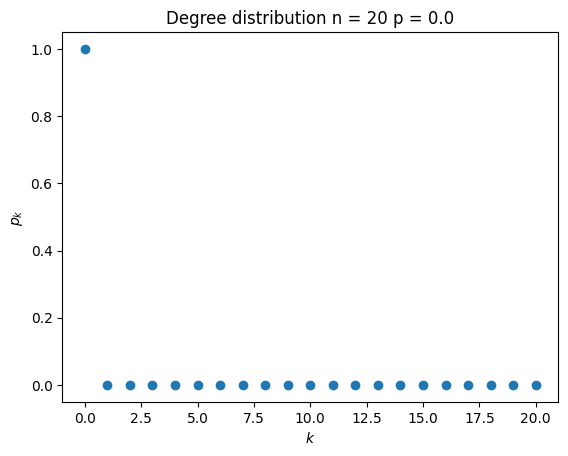

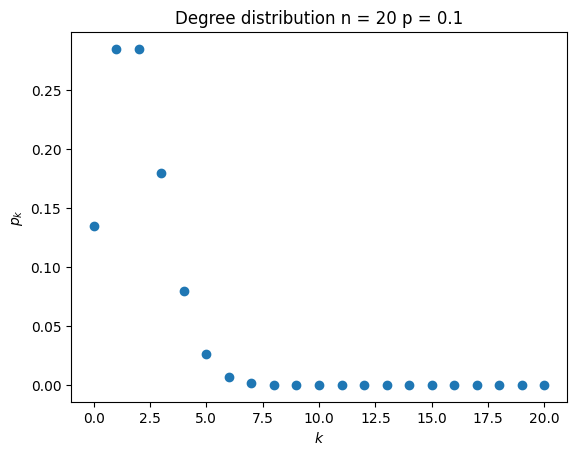

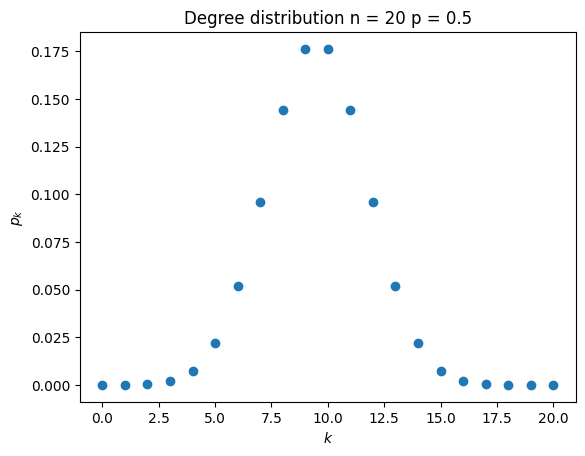

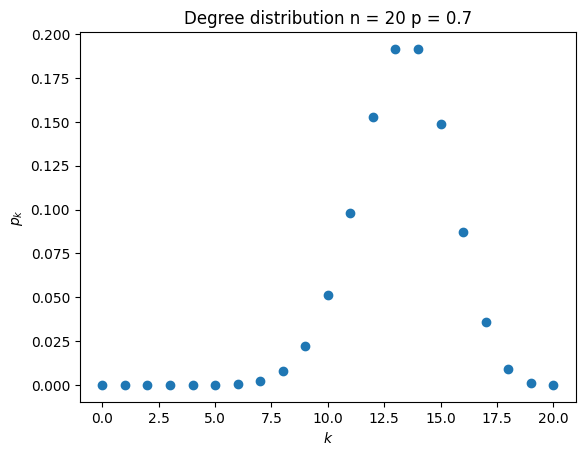

In [135]:
n = 20; p = 0.2
def p_k(n,k,p):
    return comb(n-1,k) *(p**k)* (1-p)**(n-1-k)
def show_histogram(n,p):
    k_values = []; p_values = []
    for k in range(0,n+1):
        k_values.append(k)
        p_values.append(p_k(n,k,p))
    plt.figure()
    ax = plt.gca()
    plt.scatter(k_values,p_values)
    #ax.semilogy()
    plt.title('Degree distribution n = ' + str(n) + ' p = ' + str(p))
    plt.xlabel('$k$')
    plt.ylabel("$p_k$")

""" Show degree histogram and expected degree distribution """
n = 20; p = 0.00
show_histogram(n,p)
show_histogram(n,0.1)
show_histogram(n,0.5)
show_histogram(n,0.7)


In [31]:
""" The emergence of a giant component """

p = 0; n = 20
G = nx.erdos_renyi_graph(n,p)
color_map = ['y' for node in G.nodes]
pos = nx.circular_layout(G)
plt.figure(4); plt.clf();ax = plt.gca()
plt.ion()
nx.draw(G,pos,node_color = color_map, node_size = 70, alpha=0.8)
title = "G(n,p) graph = G("+str(n) + ","+str(np.round(p,2)) + ")"
ax.set_title(title)
plt.waitforbuttonpress(.1)
while p <= 0.5:
    G = nx.erdos_renyi_graph(n,p)
    plt.clf();ax = plt.gca()
    nx.draw(G,pos,node_color = color_map, node_size = 70, alpha=0.8)
    title = "G(n,p) graph = G("+str(n) + ","+str(np.round(p,2)) + ")"
    ax.set_title(title)
    plt.waitforbuttonpress(.1)
    p += 0.01


In [32]:
""" The configuration model
Section 12.1
M. Newman, Networks 2nd edition
Oxford University Press, 2018
"""

import random  

# I want a network whose nodes have these degrees 
desired_degrees = {'n0':5, 'n1': 4, 'n2': 3, 'n3': 2};  """ Sum of desired degrees must be even! """
def index_to_nodename(index): return 'n' + str(index)
# Compute the number of edges
m = int(sum([desired_degrees[node] for node in desired_degrees.keys()])/2)
print(f"You need {m} edges for the degree sequence {[desired_degrees[node] for node in desired_degrees.keys()]}")
# Randomly choose stubs and pair them together
def getMultiGraph(desired_degrees):
    G = nx.MultiGraph()
    G.add_nodes_from(desired_degrees.keys())
    color_map = ['y' for node in G.nodes]
    pos = nx.circular_layout(G)
    # Compute stub_vector
    stub_vector = [desired_degrees[node] for node in desired_degrees.keys()]
    while sum(stub_vector) > 1:
        nodes_with_unmatched_stubs = [i for i,v in enumerate(stub_vector) if v > 0]
        node1 = random.choice(nodes_with_unmatched_stubs)
        #print(f"node {node1} was chosen with {stub_vector[node1]} stubs remaining")
        stub_vector[node1] = stub_vector[node1] - 1
        #print("new vector of stubs is ", stub_vector)
        nodes_with_unmatched_stubs = [i for i,v in enumerate(stub_vector) if v > 0]
        node2 = random.choice(nodes_with_unmatched_stubs)
        #print(f"node {node2} was chosen with {stub_vector[node2]} stubs remaining")
        stub_vector[node2] = stub_vector[node2] - 1
        #print("new vector of stubs is ", stub_vector)
        G.add_edge(index_to_nodename(node1),index_to_nodename(node2))
        #print("adding edge between ", index_to_nodename(node1), " and ", index_to_nodename(node2))
    return G, pos, color_map
G, pos, color_map = getMultiGraph(desired_degrees)
#pos = nx.nx_agraph.graphviz_layout(G,prog='neato')
#pos = nx.nx_pydot.pydot_layout(G, prog="dot")
plt.figure(5); plt.clf();ax = plt.gca()
plt.ion()
nx.draw(G,pos,node_color = color_map, with_labels = True, node_size = 400, alpha=0.8)
for e in G.edges:
    ax.annotate("",
                xy=pos[e[0]], xycoords='data',
                xytext=pos[e[1]], textcoords='data',
                arrowprops=dict(arrowstyle="-", color="0.5",
                                shrinkA=5, shrinkB=5,
                                patchA=None, patchB=None,
                                connectionstyle="arc3,rad=rrr".replace('rrr',str(0.3*e[2])
                                ),
                                ),
                )
plt.axis('off')
plt.show()
print(G.degree())
print("This algorithm creates self-loops and multi-edges")
print("It does not create graphs that satisfy the definition of \'simple\' graphs")


You need 7 edges for the degree sequence [5, 4, 3, 2]
[('n0', 5), ('n1', 4), ('n2', 3), ('n3', 2)]
This algorithm creates self-loops and multi-edges
It does not create graphs that satisfy the definition of 'simple' graphs


In [33]:
""" Can I get a better visualization? """
from networkx.drawing.nx_agraph import write_dot
write_dot(G,'multi.dot')
nx.write_gexf(G,'mutligraph.gexf')


In [34]:
""" Let's test it! """
n = 12
desired_degrees = dict()
for node in range(0,n):
    node_name = 'n' + str(node)
    desired_degrees[node_name] = node+1
G, pos, color_map = getMultiGraph(desired_degrees)
plt.figure(6); plt.clf();ax = plt.gca()
plt.ion()
nx.draw(G,pos,node_color = color_map, with_labels = True, node_size = 400, alpha=0.8)
plt.show()
print(G.degree())

""" Can I get a better visualization? """
from networkx.drawing.nx_agraph import write_dot
write_dot(G,'multi.dot')
nx.write_gexf(G,'mutligraph.gexf')


[('n0', 1), ('n1', 2), ('n2', 3), ('n3', 4), ('n4', 5), ('n5', 6), ('n6', 7), ('n7', 8), ('n8', 9), ('n9', 10), ('n10', 11), ('n11', 12)]


In [39]:
""" Draw a degree sequence from a desired degree distribution.
Networks, 2nd edition, M. Newman, Oxford University Press, p 373-375, 2018. 

p(k) distributed as k^{-\gamma}."""

g = 0.23 # real scale free networks have 2 < k < 3 (wikipedia on scale-free networks)
k = [i for i in range(1,10000)] # List of degrees
p_notNormalized = [np.power(degree,-g) for degree in k] # Probability of degree
totalP = sum(p_notNormalized)
pdf = [pr/totalP for pr in p_notNormalized]
plt.figure(7); plt.clf(); plt.ion()
plt.loglog(k,pdf)
plt.title('Desired Power Law Distribution $p(k)\sim k^{-\gamma}$')
plt.xlabel('Degree $k$')
plt.ylabel('$p(k)$')
plt.show()
print('Integrates to 1? sum over all k is ', sum(pdf))



Integrates to 1? sum over all k is  1.000000000000004


In [36]:
""" Algorithm steps for turning degree distribution into degree sequence """
cdf = np.cumsum(pdf)
plt.figure(8); plt.clf(); plt.ion()
plt.loglog(k,cdf)
plt.title('CDF of Desired Power Law Distribution $F(k)= \sum_{j=1}^k p(j)$')
plt.xlabel('Degree $k$')
plt.ylabel('$F(k)$')
plt.show()

num_nodes = 5000; n = 0
desired_degree_values = []
while n < num_nodes:
    u = np.random.uniform(0,1.0) 
    degree = min(range(len(cdf)), key=lambda i: abs(cdf[i]-u))
    desired_degree_values.append(degree)
    n += 1
    if n%1000 == 0: print("on node ", n)
    


on node  1000
on node  2000
on node  3000
on node  4000
on node  5000


In [38]:
plt.figure(9);plt.clf(); plt.ion();ax = plt.gca()
plt.hist(desired_degree_values,bins = 20)
plt.title('histogram of degrees for sample network')
plt.xlabel('degree')
plt.ylabel('number of nodes with that degree')
#plt.plot(np.sort(desired_degree_values))
ax.loglog()
plt.show()
print("Number of edges is ", sum(desired_degree_values)/2)



Number of edges is  10728926.0
